<a href="https://colab.research.google.com/github/your-org/alexpose/blob/main/experiments/multiple-sclerosis/03_sjepa_model_and_pretrain_normal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 - Build S-JEPA and pretrain (label-free)

Now we build the model and train it, with **no labels**, on the walking motion itself. S-JEPA has three parts, all small transformers:

- a **view encoder** that reads the visible joints of a slightly transformed view,
- a **predictor** that guesses the hidden joints in feature space. Crucially, it is told *which* joint and *which* time each hidden slot is (a factorized position tag), so it can make a different guess per position. Without that tag every hidden guess is identical, which was a real bug in an earlier version.
- a **target encoder** that reads the full skeleton and provides the answer. It is a slow moving average of the view encoder, which is what stops the model from collapsing every skeleton to the same features.

> **A note on what trains here.** For three-class classification the useful thing is to learn from *all* the fold's unlabeled walking, so this notebook trains label-free on every training source. Training on normal gait *only* is a different question (one-class anomaly detection); we keep that as a separate idea, not the default.


In [1]:
# --- Setup: install dependencies (Colab installs; local usually already has them) ---
import importlib, importlib.util, subprocess, sys, os

IN_COLAB = 'google.colab' in sys.modules

def _need(mod):
    return importlib.util.find_spec(mod) is None

# Light deps used by every notebook.
_pkgs = []
for mod, pip_name in [('cv2','opencv-python'), ('mediapipe','mediapipe'),
                      ('sklearn','scikit-learn'), ('pandas','pandas'),
                      ('matplotlib','matplotlib'), ('tqdm','tqdm')]:
    if _need(mod):
        _pkgs.append(pip_name)
# torch is guarded so Colab's preinstalled GPU torch is never downgraded.
if _need('torch'):
    _pkgs.append('torch')
if _pkgs:
    print('installing:', _pkgs)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *_pkgs])
else:
    print('all light dependencies already present')

all light dependencies already present


In [2]:
# --- Make `sjepa` and `ambient` importable, locally and in Colab ---
from pathlib import Path
import sys, subprocess

def _find_exp_dir():
    # Local run: this notebook sits in experiments/multiple-sclerosis.
    here = Path.cwd()
    for p in [here, *here.parents]:
        if (p / 'sjepa' / '__init__.py').exists():
            return p
    return None

EXP_DIR = _find_exp_dir()
if EXP_DIR is None:
    # Colab: clone the repo, then point at the experiment folder.
    REPO = 'https://github.com/your-org/alexpose.git'  # <-- edit to your fork
    if not Path('alexpose').exists():
        subprocess.check_call(['git', 'clone', '--depth', '1', REPO])
    EXP_DIR = Path('alexpose') / 'experiments' / 'multiple-sclerosis'

REPO_ROOT = EXP_DIR.parents[1]
for p in (str(EXP_DIR), str(REPO_ROOT)):
    if p not in sys.path:
        sys.path.insert(0, p)
print('experiment dir:', EXP_DIR)
print('repo root     :', REPO_ROOT)

experiment dir: /Users/pmui/dev/alexpose/experiments/multiple-sclerosis
repo root     : /Users/pmui/dev/alexpose


In [3]:
# --- Paths and profile (reads the root .env if python-dotenv is present) ---
import os
try:
    from dotenv import load_dotenv
    load_dotenv(REPO_ROOT / '.env')
except Exception:
    pass

VIDEO_DIR = EXP_DIR / 'video-data'
ARTIFACT_DIR = EXP_DIR / 'artifacts'
KEYPOINTS_DIR = ARTIFACT_DIR / 'keypoints'
IMAGES_DIR = EXP_DIR / 'images'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Pick the model size profile. 'laptop' is the fast default; set SJEPA_PROFILE=gpu
# in your .env for a larger model, or SJEPA_SMOKE=1 for a near-instant test run.
os.environ.setdefault('SJEPA_PROFILE', 'laptop')
print('SJEPA_PROFILE =', os.environ['SJEPA_PROFILE'],
      '| SJEPA_SMOKE =', os.environ.get('SJEPA_SMOKE', '0'))

SJEPA_PROFILE = laptop | SJEPA_SMOKE = 0


## The two-lane design

The picture below is the whole idea. The top lane makes a prediction from a masked view. The bottom lane makes the target from the complete skeleton with a slow teacher. They meet only at the loss.


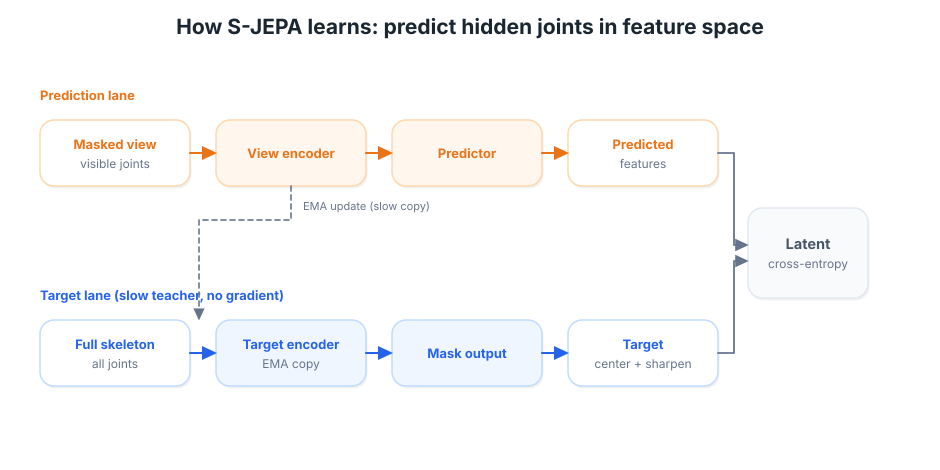

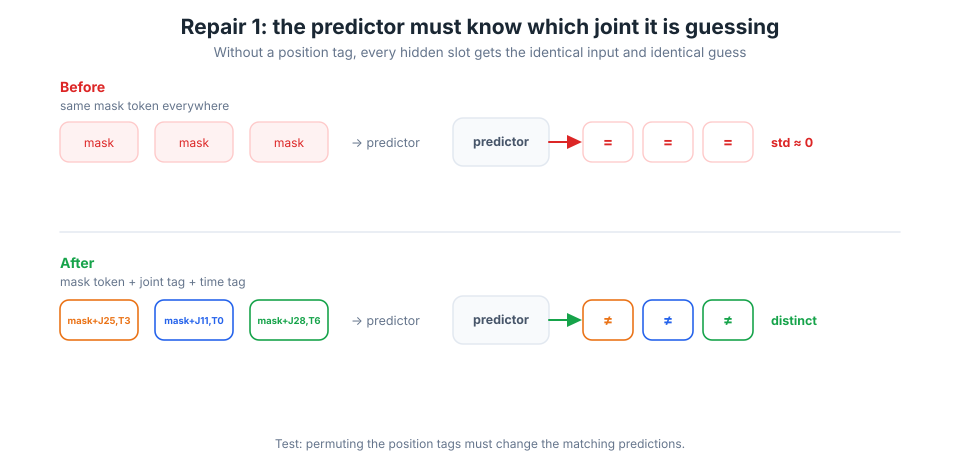

In [4]:
from IPython.display import SVG, display
display(SVG(filename=str(IMAGES_DIR / 'sjepa_two_lane.svg')))
display(SVG(filename=str(IMAGES_DIR / 'defect_predictor_positions.svg')))

In [5]:
from sjepa.config import get_config, describe
from sjepa.models import build_model, pick_device

cfg = get_config()
device = pick_device()
print('device:', device)
print(describe(cfg))
model = build_model(cfg, device=device, repaired=True)  # PredictorV2 + per-example masks
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'trainable parameters: {n_params/1e6:.2f}M')

device: mps
profile=laptop | window=32f @ 15fps | tokens N=264 (8 time x 33 joints) | encoder 3L x 96d x 4h | predictor 2L x 96d | pretrain 40ep, finetune 30ep
trainable parameters: 0.40M


## Load the training windows (fold 0's training sources, no labels)

We train the self-supervised encoder on the **training half of the locked fold 0** only, never on the videos held out for testing. This matters even though the objective ignores labels: if the encoder saw a held-out video's motion during self-supervised training, then the probe scores that notebooks 04 and 06 report on that video would no longer be honest held-out numbers. So we load the same `g1` fold registry the later notebooks use and cut windows from its fold 0 training sources. The label still rides along, unused by the objective, only so later notebooks can score.


In [6]:
import json
from sjepa.data import load_index, SequenceWindowDataset

records = load_index(KEYPOINTS_DIR)
by_clip = {r.clip_name: r for r in records}
registry = json.loads((ARTIFACT_DIR / 'eval' / 'g1' / 'fold_registry.json').read_text())
fold0 = registry['folds'][0]
train_recs = [by_clip[c] for c in fold0['train_clips']]
test_srcs = {by_clip[c].source_id for c in fold0['test_clips']}
assert not ({r.source_id for r in train_recs} & test_srcs), 'held-out source leaked into SSL'
ds_train = SequenceWindowDataset(train_recs, cfg.window_frames, cfg.window_stride)
print(f'fold 0 training half: {len(train_recs)} videos -> {len(ds_train)} windows',
      '(labels unused in SSL; held-out videos excluded)')

fold 0 training half: 37 videos -> 395 windows (labels unused in SSL; held-out videos excluded)


## Train

We run the two-lane objective for a fixed number of **optimizer updates** (not epochs), sampling sources uniformly so a long clip cannot dominate, and nudge the teacher with a responsive EMA. We log the loss and collapse diagnostics: the per-dimension spread, the effective rank (how many directions the features really use), and how far the teacher has drifted from the student.


In [7]:
from sjepa.train_v2 import train_sjepa_v2, save_checkpoint_v2

# A small update budget keeps the notebook fast; raise it for stronger features.
# `cfg.profile` ends in '+smoke' only when SJEPA_SMOKE is truthy (the config parses
# '0'/'1'/'true' correctly, unlike a raw os.environ.get truthiness test).
SMOKE = cfg.profile.endswith('smoke')
UPDATES = 60 if SMOKE else 800
state = train_sjepa_v2(model, ds_train, cfg, total_updates=UPDATES, device=device,
                       mask_ratio=0.6, log_every=max(1, UPDATES // 4))
save_checkpoint_v2(ARTIFACT_DIR / 'sjepa_ssl.pt', model, cfg, train_state=state,
                   extra={'stage': 'ssl_fold0_train'})
print('EMA half-life (steps):', round(state.ema_half_life_steps, 1))

step     0 loss 6.0458 lr 1.25e-05 tau 0.99600 emb_std 0.1485 eff_rank 7.9
step   200 loss 2.0674 lr 9.33e-04 tau 0.99659 emb_std 0.1815 eff_rank 7.4
step   400 loss 1.3479 lr 5.87e-04 tau 0.99800 emb_std 0.3536 eff_rank 8.8
step   600 loss 1.3662 lr 1.79e-04 tau 0.99941 emb_std 0.4783 eff_rank 10.5
EMA half-life (steps): 346.2


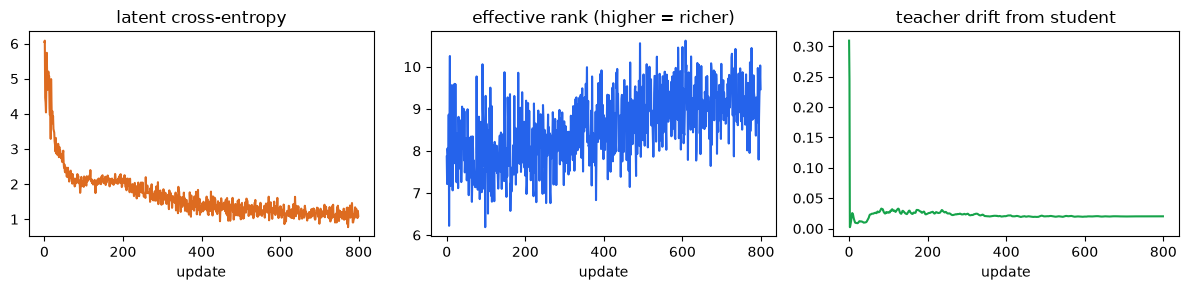

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(state.losses, color='#dd6b20'); ax[0].set_title('latent cross-entropy')
ax[1].plot(state.eff_rank, color='#2563eb'); ax[1].set_title('effective rank (higher = richer)')
ax[2].plot(state.teacher_drift, color='#16a34a'); ax[2].set_title('teacher drift from student')
for a in ax: a.set_xlabel('update')
plt.tight_layout(); plt.show()

### Sanity checks

We avoid weak checks. A falling loss is necessary but not sufficient: a collapsed model can also lower the loss. So we also require the effective rank to stay well above 1 (the features use many directions, not one) and the teacher to have moved.


In [9]:
import numpy as np
early = np.mean(state.losses[:5]); late = np.mean(state.losses[-5:])
print(f'loss {early:.3f} -> {late:.3f} | final effective rank {state.eff_rank[-1]:.1f}')
assert np.isfinite(state.losses).all(), 'loss went non-finite'
assert state.eff_rank[-1] > 1.5, 'representation looks collapsed (effective rank near 1)'
assert state.teacher_drift[-1] >= 0, 'teacher drift should be finite and non-negative'
print('SSL looks healthy (no collapse). On to comparing training regimes.')

loss 4.990 -> 1.112 | final effective rank 9.5
SSL looks healthy (no collapse). On to comparing training regimes.
